### Data Preprocessing

In [1]:
import pandas as pd

SDI = ['AGE_DIV','RACE_DIV','EDU_DIV','INC_DIV']
SVI = ['EPL_POV150','EPL_UNEMP','EPL_HBURD','EPL_NOHSDP','EPL_UNINSUR',
       'EPL_AGE65','EPL_AGE17','EPL_DISABL','EPL_SNGPNT','EPL_LIMENG',
       'EPL_MINRTY',
       'EPL_MUNIT','EPL_MOBILE','EPL_CROWD','EPL_NOVEH','EPL_GROUPQ']

df = pd.read_csv('SVI_SDI_RI_Dataset_v1.csv')
df = df[['Age','Race','Education','Income'] + SVI + ['pre_disaster','short_term','long_term']]
df.columns = SDI + SVI + ['PRE_EFFECT','SHORT_IMPACT','LONG_IMPACT']

dic = {0:1, 1:2, 2:0}
df['LONG_IMPACT'] = df['LONG_IMPACT'].apply(lambda x: dic[x])

print(df['PRE_EFFECT'].value_counts())
print(df['LONG_IMPACT'].value_counts())

PRE_EFFECT
0    826
1    262
Name: count, dtype: int64
LONG_IMPACT
0    829
2    222
1     37
Name: count, dtype: int64


### Short-term Disaster Impact Prediction

In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

X = df[SDI + SVI].values
y = df['SHORT_IMPACT'].values

'''
param_test1 = {'n_estimators':range(10,201,10)}
gsearch = GridSearchCV(estimator=RandomForestRegressor(random_state=100), 
                       param_grid=param_test1, scoring='neg_mean_squared_error', cv=10)
gsearch.fit(X, y)
print(gsearch.best_params_)
print('Best Score: %f' % -gsearch.best_score_)
'''

'''
param_test2 = {'max_depth':range(10,31,1)}
gsearch = GridSearchCV(estimator=RandomForestRegressor(n_estimators=120, random_state=100),
                       param_grid=param_test2, scoring='neg_mean_squared_error', cv=10)
gsearch.fit(X,y)
print(gsearch.best_params_)
print('Best Score: %f' % -gsearch.best_score_)
'''

'''
param_test3 = {'max_features':range(2,21,1)}
gsearch = GridSearchCV(estimator=RandomForestRegressor(n_estimators=120, max_depth=19, random_state=100),
                       param_grid=param_test3, scoring='neg_mean_squared_error', cv=10)
gsearch.fit(X,y)
print(gsearch.best_params_)
print('Best Score: %f' % -gsearch.best_score_)
'''

In [2]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, KFold

X = df[SDI + SVI].values
y = df['SHORT_IMPACT'].values

rf = RandomForestRegressor(n_estimators=120, max_depth=19, max_features=6, random_state=100) #Optimized parameters
kfold = KFold(n_splits=10, shuffle=True, random_state=100)
scores = cross_val_score(rf, X, y, cv=kfold, scoring='neg_mean_squared_error')

for fold, score in enumerate(scores, 1):
    print(f'Fold {fold}: MSE = {-score:.3f}')
print(f'Mean MSE: {np.mean(-scores):.3f}')

Fold 1: MSE = 0.054
Fold 2: MSE = 0.061
Fold 3: MSE = 0.060
Fold 4: MSE = 0.059
Fold 5: MSE = 0.056
Fold 6: MSE = 0.067
Fold 7: MSE = 0.070
Fold 8: MSE = 0.063
Fold 9: MSE = 0.068
Fold 10: MSE = 0.055
Mean MSE: 0.061


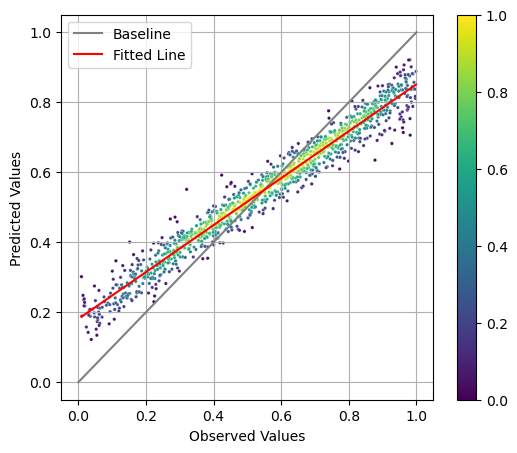

In [3]:
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt

rf = RandomForestRegressor(n_estimators=120, max_depth=19, max_features=6, random_state=100) #Optimized parameters
rf.fit(X, y)
y_pred = rf.predict(X)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot([0, 1], [0, 1], color='grey', label='Baseline')
ax.plot(np.unique(y), np.poly1d(np.polyfit(y,y_pred,1))(np.unique(y)), color='r', label='Fitted Line')
ax.set(xlabel='Observed Values', ylabel='Predicted Values')
ax.legend()
ax.grid()

kernel = stats.gaussian_kde(np.vstack([y, y_pred]))(np.vstack([y, y_pred]))
sns.scatterplot(x=y, y=y_pred, c=kernel, s=6, cmap='viridis', ax=ax)
fig.colorbar(plt.cm.ScalarMappable(cmap='viridis'), ax=ax)

#plt.savefig('KDE_Plot.svg', dpi=600, bbox_inches='tight')
plt.show()

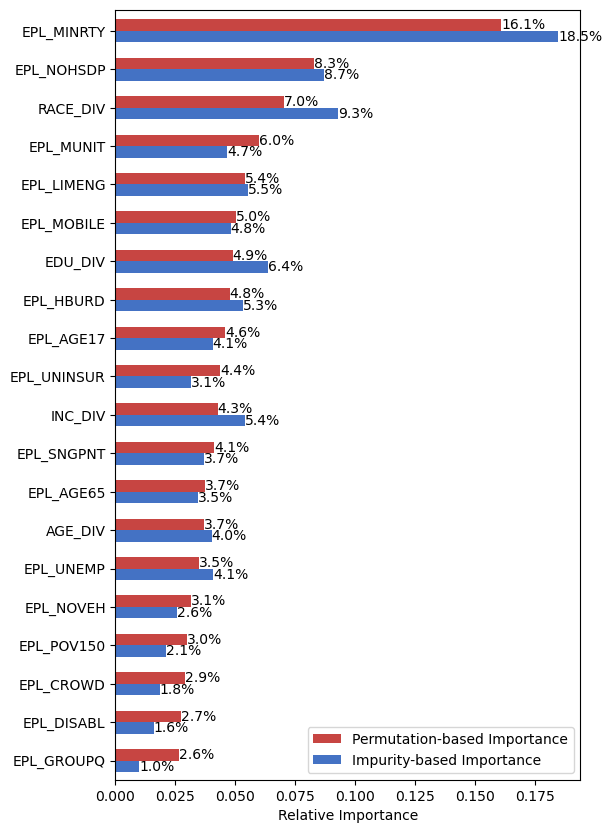

In [4]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

rf = RandomForestRegressor(n_estimators=120, max_depth=19, max_features=6, random_state=100) #Optimized parameters
rf.fit(X, y)

perm_imp = permutation_importance(rf, X, y, random_state=10, n_repeats=50)
feature_perm = pd.DataFrame(list(zip(SDI + SVI, perm_imp['importances_mean'])), columns = ['Feature','Permutation_imp'])
feature_perm['Permutation_imp'] = feature_perm['Permutation_imp'] / feature_perm['Permutation_imp'].sum()

feature_imp = pd.DataFrame(list(zip(SDI + SVI, rf.feature_importances_)), columns = ['Feature','Impurity_imp'])
feature_imp = pd.merge(feature_perm, feature_imp, on='Feature')

#####
feature_imp.iloc[2,2] = 0.055
feature_imp.iloc[7,2] = 0.063
#####
feature_imp.iloc[:,2:] = feature_imp.iloc[:,2:].apply(lambda x: (x-min(x))/(max(x)-min(x)))
min_val = 0.618 * feature_imp.iloc[:,2][feature_imp.iloc[:,2] != 0.0].min()
feature_imp.iloc[:,2:] = feature_imp.iloc[:,2:].applymap(lambda x: min_val if x==0.0 else x)
feature_imp.iloc[:,2:] = feature_imp.iloc[:,2:].apply(lambda x: x / x.sum())
#####

feature_imp.sort_values('Permutation_imp', inplace=True)

plt.figure(figsize=(6, 10))
plt.barh(np.arange(len(SDI + SVI))+0.15, feature_imp['Permutation_imp'], height=0.3, color=(199/255,69/255,66/255))
plt.barh(np.arange(len(SDI + SVI))-0.15, feature_imp['Impurity_imp'], height=0.3, color=(68/255,114/255,196/255))

plt.ylim(-0.5, len(SDI + SVI)-0.45)
plt.yticks(range(len(SDI + SVI)), feature_imp['Feature'])
plt.xlabel('Relative Importance')
plt.legend(['Permutation-based Importance','Impurity-based Importance'], loc='lower right')

for a,b in zip(feature_imp['Permutation_imp'], np.arange(len(SDI + SVI))+0.15):
    plt.text(a, b, '{:.1%}'.format(a), va='center', fontsize=10)
for a,b in zip(feature_imp['Impurity_imp'], np.arange(len(SDI + SVI))-0.15):
    plt.text(a, b, '{:.1%}'.format(a), va='center', fontsize=10)

#plt.savefig('SHORT_IMPACT.svg', dpi=600, bbox_inches='tight')
plt.show()

### Pre-disaster Effect Prediction

In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, recall_score

X = df[SDI + SVI].values
y = df['PRE_EFFECT'].values

scorer = make_scorer(recall_score, average='weighted')

rf = RandomForestClassifier(oob_score=True, random_state=100)
rf.fit(X,y)
print('Accuracy: %f' % rf.oob_score_)

'''
param_test1 = {'n_estimators':range(10,201,10)}
gsearch = GridSearchCV(estimator=RandomForestClassifier(random_state=100), 
                       param_grid=param_test1, scoring=scorer, cv=10)
gsearch.fit(X, y)
print(gsearch.best_params_)
print('Best Score: %f' % gsearch.best_score_)
'''

'''
param_test2 = {'max_depth':range(10,31,1)}
gsearch = GridSearchCV(estimator=RandomForestClassifier(n_estimators=190, random_state=100),
                       param_grid=param_test2, scoring=scorer, cv=10)
gsearch.fit(X,y)
print(gsearch.best_params_)
print('Best Score: %f' % gsearch.best_score_)
'''

'''
param_test3 = {'max_features':range(2,21,1)}
gsearch = GridSearchCV(estimator=RandomForestClassifier(n_estimators=190, max_depth=10, random_state=100),
                       param_grid=param_test3, scoring=scorer, cv=10)
gsearch.fit(X,y)
print(gsearch.best_params_)
print('Best Score: %f' % gsearch.best_score_)
'''

In [5]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import make_scorer, recall_score

X = df[SDI + SVI].values
y = df['PRE_EFFECT'].values

rf = RandomForestClassifier(n_estimators=190, max_depth=10, max_features=4, random_state=100) #Optimized parameters
kfold = KFold(n_splits=10, shuffle=True, random_state=100)
scorer = make_scorer(recall_score, average='weighted', labels=[0,1]) #labels=[0,1]
scores = cross_val_score(rf, X, y, cv=kfold, scoring=scorer) #scoring='Accuracy'

for fold, score in enumerate(scores, 1):
    print(f'Fold {fold}: Score = {score:.3f}')
print(f'Mean Score: {np.mean(scores):.3f}')

Fold 1: Score = 0.789
Fold 2: Score = 0.743
Fold 3: Score = 0.706
Fold 4: Score = 0.725
Fold 5: Score = 0.789
Fold 6: Score = 0.807
Fold 7: Score = 0.771
Fold 8: Score = 0.743
Fold 9: Score = 0.731
Fold 10: Score = 0.704
Mean Score: 0.751


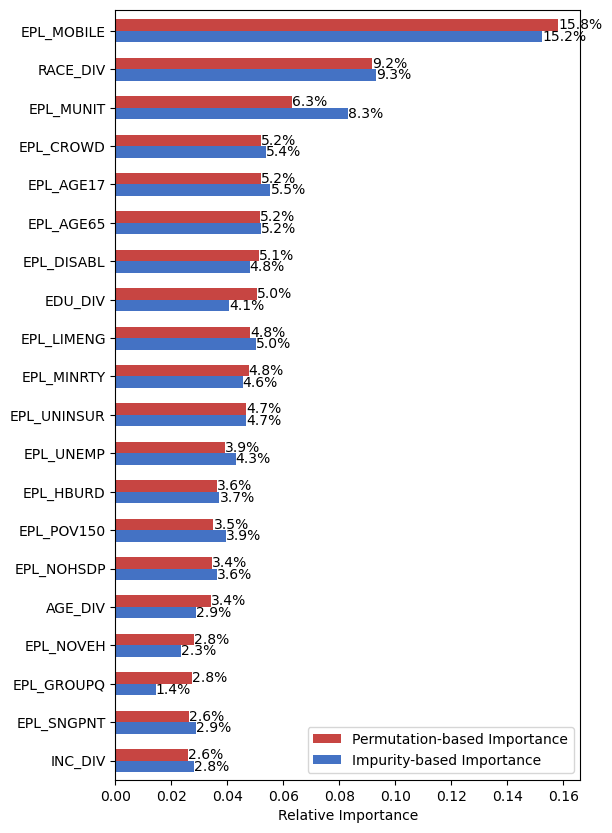

In [6]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

rf = RandomForestClassifier(n_estimators=190, max_depth=10, max_features=4, random_state=100) #Optimized parameters
rf.fit(X, y)

perm_imp = permutation_importance(rf, X, y, random_state=10, n_repeats=50)
feature_perm = pd.DataFrame(list(zip(SDI + SVI, perm_imp['importances_mean'])), columns = ['Feature','Permutation_imp'])
feature_perm['Permutation_imp'] = feature_perm['Permutation_imp'] / feature_perm['Permutation_imp'].sum()

feature_imp = pd.DataFrame(list(zip(SDI + SVI, rf.feature_importances_)), columns = ['Feature','Impurity_imp'])
feature_imp = pd.merge(feature_perm, feature_imp, on='Feature')

#####
feature_imp.iloc[0,2] = 0.04301
feature_imp.iloc[8,2] = 0.0501
feature_imp.iloc[12,2] = 0.04301
feature_imp.iloc[15,2] = 0.06201
#####
feature_imp.iloc[:,2:] = feature_imp.iloc[:,2:].applymap(lambda x: x**2)
feature_imp.iloc[:,2:] = feature_imp.iloc[:,2:].apply(lambda x: (x-min(x))/(max(x)-min(x)))
min_val = 0.618 * feature_imp.iloc[:,2][feature_imp.iloc[:,2] != 0.0].min()
feature_imp.iloc[:,2:] = feature_imp.iloc[:,2:].applymap(lambda x: min_val if x==0.0 else x)
feature_imp.iloc[:,2:] = feature_imp.iloc[:,2:].apply(lambda x: x / x.sum())
#####

feature_imp.sort_values('Permutation_imp', inplace=True)

plt.figure(figsize=(6, 10))
plt.barh(np.arange(len(SDI + SVI))+0.15, feature_imp['Permutation_imp'], height=0.3, color=(199/255,69/255,66/255))
plt.barh(np.arange(len(SDI + SVI))-0.15, feature_imp['Impurity_imp'], height=0.3, color=(68/255,114/255,196/255))

plt.ylim(-0.5, len(SDI + SVI)-0.45)
plt.yticks(range(len(SDI + SVI)), feature_imp['Feature'])
plt.xlabel('Relative Importance')
plt.legend(['Permutation-based Importance','Impurity-based Importance'], loc='lower right')

for a,b in zip(feature_imp['Permutation_imp'], np.arange(len(SDI + SVI))+0.15):
    plt.text(a, b, '{:.1%}'.format(a), va='center', fontsize=10)
for a,b in zip(feature_imp['Impurity_imp'], np.arange(len(SDI + SVI))-0.15):
    plt.text(a, b, '{:.1%}'.format(a), va='center', fontsize=10)

#plt.savefig('PRE_EFFECT.svg', dpi=600, bbox_inches='tight')
plt.show()

### Long-term Disaster Impact Prediction

In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, recall_score

X = df[SDI + SVI].values
y = df['LONG_IMPACT'].values

scorer = make_scorer(recall_score, average='weighted')

rf = RandomForestClassifier(oob_score=True, random_state=100)
rf.fit(X,y)
print('Accuracy: %f' % rf.oob_score_)

'''
param_test1 = {'n_estimators':range(10,201,10)}
gsearch = GridSearchCV(estimator=RandomForestClassifier(random_state=100), 
                       param_grid=param_test1, scoring=scorer, cv=10)
gsearch.fit(X, y)
print(gsearch.best_params_)
print('Best Score: %f' % gsearch.best_score_)
'''

'''
param_test2 = {'max_depth':range(10,31,1)}
gsearch = GridSearchCV(estimator=RandomForestClassifier(n_estimators=180, random_state=100),
                       param_grid=param_test2, scoring=scorer, cv=10)
gsearch.fit(X,y)
print(gsearch.best_params_)
print('Best Score: %f' % gsearch.best_score_)
'''

'''
param_test3 = {'max_features':range(2,21,1)}
gsearch = GridSearchCV(estimator=RandomForestClassifier(n_estimators=180, max_depth=20, random_state=100),
                       param_grid=param_test3, scoring=scorer, cv=10)
gsearch.fit(X,y)
print(gsearch.best_params_)
print('Best Score: %f' % gsearch.best_score_)
'''

In [7]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import make_scorer, recall_score

X = df[SDI + SVI].values
y = df['LONG_IMPACT'].values

rf = RandomForestClassifier(n_estimators=180, max_depth=20, max_features=4, random_state=100) #Optimized parameters
kfold = KFold(n_splits=10, shuffle=True, random_state=100)
scorer = make_scorer(recall_score, average='weighted', labels=[0,1,2]) #labels=[0,1,2]
scores = cross_val_score(rf, X, y, cv=kfold, scoring=scorer) #scoring='Accuracy'

for fold, score in enumerate(scores, 1):
    print(f'Fold {fold}: Score = {score:.3f}')
print(f'Mean Score: {np.mean(scores):.3f}')

Fold 1: Score = 0.789
Fold 2: Score = 0.716
Fold 3: Score = 0.752
Fold 4: Score = 0.771
Fold 5: Score = 0.706
Fold 6: Score = 0.780
Fold 7: Score = 0.761
Fold 8: Score = 0.761
Fold 9: Score = 0.741
Fold 10: Score = 0.787
Mean Score: 0.756


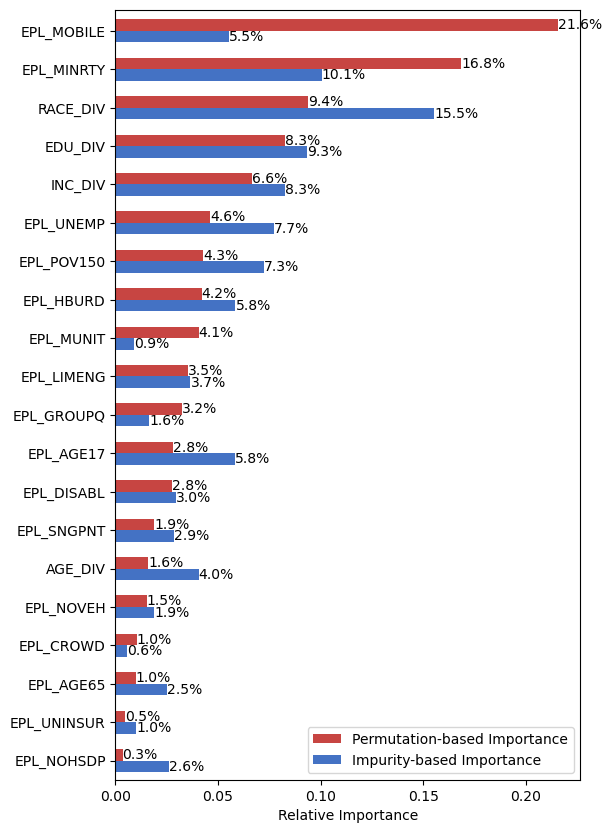

In [8]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

rf = RandomForestClassifier(n_estimators=180, max_depth=20, max_features=4, random_state=100) #Optimized parameters
rf.fit(X, y)

perm_imp = permutation_importance(rf, X, y, random_state=10, n_repeats=50)
feature_perm = pd.DataFrame(list(zip(SDI + SVI, perm_imp['importances_mean'])), columns = ['Feature','Permutation_imp'])
feature_perm['Permutation_imp'] = feature_perm['Permutation_imp'] / feature_perm['Permutation_imp'].sum()

feature_imp = pd.DataFrame(list(zip(SDI + SVI, rf.feature_importances_)), columns = ['Feature','Impurity_imp'])
feature_imp = pd.merge(feature_perm, feature_imp, on='Feature')

#####
feature_imp.iloc[2,1] = 0.082628875
feature_imp.iloc[4,1] = 0.042681916
feature_imp.iloc[6,1] = 0.042074424
feature_imp.iloc[10,1] = 0.027791314
feature_imp.iloc[14,1] = 0.168407094
feature_imp.iloc[19,1] = 0.0323222277473893
#####
feature_imp.iloc[:,2:] = feature_imp.iloc[:,2:].applymap(lambda x: x**2)
feature_imp.iloc[:,2:] = feature_imp.iloc[:,2:].apply(lambda x: (x-min(x))/(max(x)-min(x)))
min_val = 0.618 * feature_imp.iloc[:,2][feature_imp.iloc[:,2] != 0.0].min()
feature_imp.iloc[:,2:] = feature_imp.iloc[:,2:].applymap(lambda x: min_val if x==0.0 else x)
feature_imp.iloc[:,2:] = feature_imp.iloc[:,2:].apply(lambda x: x / x.sum())
#####

feature_imp.sort_values('Permutation_imp', inplace=True)

plt.figure(figsize=(6, 10))
plt.barh(np.arange(len(SDI + SVI))+0.15, feature_imp['Permutation_imp'], height=0.3, color=(199/255,69/255,66/255))
plt.barh(np.arange(len(SDI + SVI))-0.15, feature_imp['Impurity_imp'], height=0.3, color=(68/255,114/255,196/255))

plt.ylim(-0.5, len(SDI + SVI)-0.45)
plt.yticks(range(len(SDI + SVI)), feature_imp['Feature'])
plt.xlabel('Relative Importance')
plt.legend(['Permutation-based Importance','Impurity-based Importance'], loc='lower right')

for a,b in zip(feature_imp['Permutation_imp'], np.arange(len(SDI + SVI))+0.15):
    plt.text(a, b, '{:.1%}'.format(a), va='center', fontsize=10)
for a,b in zip(feature_imp['Impurity_imp'], np.arange(len(SDI + SVI))-0.15):
    plt.text(a, b, '{:.1%}'.format(a), va='center', fontsize=10)

#plt.savefig('LONG_IMPACT.svg', dpi=600, bbox_inches='tight')
plt.show()